# Phase 3.5: Fine-Tuning TrOCR-Small for Hindi HTR

**Goal:** >96% char accuracy, >92% word accuracy

**Key improvements over v1:**
- More Phase B epochs (15 vs 12) for better convergence
- SWA with proper BN-skip fix
- Smart embedding initialization
- Test-Time Augmentation (TTA)

**Platform:** Kaggle T4 GPU | ~8-10 hours

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "transformers>=4.38", "datasets", "evaluate", "jiwer",
    "editdistance", "accelerate", "sentencepiece"])
print("All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 43.7 MB/s eta 0:00:00
All packages installed.


## 1. Imports & Configuration

In [2]:
import json, os, time, random, unicodedata, warnings, urllib.request
from pathlib import Path
from io import BytesIO
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import editdistance

from transformers import (
    VisionEncoderDecoderModel,
    TrOCRProcessor,
    get_scheduler,
)

warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
random.seed(42); np.random.seed(42); torch.manual_seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Paths
DATASET_DIR = Path("/kaggle/input/datasets/nehamalik10/hindi-ocr-new-dataset")
PHASE2_DIR  = Path("/kaggle/input/datasets/nehamalik10/hindi-htr-phase2-artifacts-improved")
OUTPUT_DIR  = Path("/kaggle/working/phase3_5")
CKPT_DIR    = OUTPUT_DIR / "checkpoints"
RESULTS_DIR = OUTPUT_DIR / "results"
for d in [OUTPUT_DIR, CKPT_DIR, RESULTS_DIR]: d.mkdir(parents=True, exist_ok=True)

# Hyperparameters — PROVEN v1 values + more epochs
MODEL_NAME       = "microsoft/trocr-small-handwritten"
MAX_TARGET_LEN   = 32
BATCH_SIZE       = 16
EPOCHS_PHASE_A   = 3
EPOCHS_PHASE_B   = 15           # 3 more than v1 (was 12)
LR_ENCODER       = 1e-5         # v1 proven value
LR_DECODER       = 5e-5         # v1 proven value
WEIGHT_DECAY     = 0.01
WARMUP_STEPS     = 500          # v1 proven value
GRAD_CLIP        = 1.0
EVAL_SAMPLES     = 2000         # v1 proven value
NUM_BEAMS_TEST   = 8
NUM_WORKERS      = 2

print("Configuration ready.")
print(f"  Phase A: {EPOCHS_PHASE_A} epochs (decoder only, LR={LR_DECODER})")
print(f"  Phase B: {EPOCHS_PHASE_B} epochs (full, enc LR={LR_ENCODER}, dec LR={LR_DECODER})")
print(f"  Total:   {EPOCHS_PHASE_A + EPOCHS_PHASE_B} epochs")
print(f"  Warmup steps: {WARMUP_STEPS}")


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Configuration ready.
  Phase A: 3 epochs (decoder only, LR=5e-05)
  Phase B: 15 epochs (full, enc LR=1e-05, dec LR=5e-05)
  Total:   18 epochs
  Warmup steps: 500


## 2. Devanagari Font Setup

In [3]:
FONT_DIR = Path("/kaggle/working/fonts"); FONT_DIR.mkdir(exist_ok=True)
FONT_PATH = FONT_DIR / "NotoSansDevanagari.ttf"
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/notosansdevanagari/NotoSansDevanagari%5Bwdth%2Cwght%5D.ttf"
if not FONT_PATH.exists():
    for c in [Path("/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf")]:
        if c.exists(): FONT_PATH.write_bytes(c.read_bytes()); break
    else:
        print("Downloading font..."); urllib.request.urlretrieve(FONT_URL, FONT_PATH)
fm.fontManager.addfont(str(FONT_PATH))
DEVA_FONT = fm.FontProperties(fname=str(FONT_PATH))
mpl.rcParams["axes.unicode_minus"] = False
print("Font ready.")


Font ready.


## 3. Load Phase 2 Artifacts

In [4]:
with open(PHASE2_DIR / "char_vocab.json", "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
phase2_c2i = vocab_data["char_to_idx"]
phase2_i2c = {int(k): v for k, v in vocab_data["idx_to_char"].items()}
with open(PHASE2_DIR / "preprocess_config.json", "r") as f:
    preprocess_config = json.load(f)

CTC_SPECIAL = {"<BLANK>", "<UNK>", "<PAD>"}
actual_chars = sorted([ch for ch in phase2_c2i if ch not in CTC_SPECIAL],
                      key=lambda c: phase2_c2i[c])
print(f"Phase 2 vocab: {len(phase2_c2i)} entries, {len(actual_chars)} actual characters")
print(f"Sample: {actual_chars[:8]} ... {actual_chars[-3:]}")


Phase 2 vocab: 139 entries, 136 actual characters
Sample: [' ', '!', '"', '#', '%', "'", '(', ')'] ... ['\u200d', '“', '”']


## 4. Custom Devanagari Tokenizer

Character-level tokenizer: each Devanagari character -> unique token ID.

Special tokens: `<pad>=0, <bos>=1, <eos>=2, <unk>=3`

In [5]:
PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3

char_to_token = {}
token_to_char = {}
for i, ch in enumerate(actual_chars):
    tid = i + 4
    char_to_token[ch] = tid
    token_to_char[tid] = ch
VOCAB_SIZE = 4 + len(actual_chars)

def encode_text(text):
    text = unicodedata.normalize("NFC", text)
    ids = [char_to_token.get(ch, UNK_ID) for ch in text]
    ids.append(EOS_ID)
    return ids

def decode_tokens(token_ids):
    chars = []
    for tid in token_ids:
        if isinstance(tid, torch.Tensor): tid = tid.item()
        if tid == EOS_ID or tid == PAD_ID: break
        if tid == BOS_ID: continue
        if tid in token_to_char: chars.append(token_to_char[tid])
    return "".join(chars)

# Roundtrip test
test_texts = ["\u0939\u093f\u0928\u094d\u0926\u0940", "\u092d\u093e\u0930\u0924", "\u0915\u0947 \u0932\u093f\u090f"]
print(f"Vocab size: {VOCAB_SIZE}")
for t in test_texts:
    d = decode_tokens(encode_text(t))
    print(f"  '{t}' roundtrip: {'PASS' if d == t else 'FAIL: ' + d}")
print("Tokenizer ready.")


Vocab size: 140
  'हिन्दी' roundtrip: PASS
  'भारत' roundtrip: PASS
  'के लिए' roundtrip: PASS
Tokenizer ready.


## 5. Load Dataset

In [6]:
train_df = pd.read_parquet(DATASET_DIR / "train.parquet")
val_df   = pd.read_parquet(DATASET_DIR / "val.parquet")
test_df  = pd.read_parquet(DATASET_DIR / "test.parquet")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name:5s}: {len(df):>7,}")
print(f"Columns: {train_df.columns.tolist()}")


  Train: 150,000
  Val  :  20,000
  Test :  30,000
Columns: ['image_name', 'image', 'text']


## 6. Image Preprocessing & Augmentation

**Pipeline:** Raw image -> grayscale -> autocontrast -> tight crop -> RGB -> augmentation -> TrOCR processor

In [7]:
IMG_COL, LABEL_COL = "image", "text"
TIGHT_CROP_PAD = 2

def row_to_image(row):
    value = row[IMG_COL]
    if isinstance(value, Image.Image): return value.convert("RGB")
    if isinstance(value, dict):
        if value.get("bytes") is not None:
            return Image.open(BytesIO(value["bytes"])).convert("RGB")
        if value.get("path") is not None:
            return Image.open(value["path"]).convert("RGB")
    if isinstance(value, (bytes, bytearray)):
        return Image.open(BytesIO(value)).convert("RGB")
    if isinstance(value, np.ndarray):
        return Image.fromarray(value).convert("RGB")
    raise TypeError(f"Unsupported image type: {type(value)}")

def preprocess_for_trocr(pil_img):
    """v1 PROVEN: grayscale + contrast normalize + tight crop + back to RGB."""
    gray = np.array(pil_img.convert("L"))
    p2, p98 = np.percentile(gray, (2, 98))
    if p98 > p2:
        gray = np.clip((gray - p2) / (p98 - p2) * 255, 0, 255).astype(np.uint8)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = cv2.findNonZero(bw)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        pad = TIGHT_CROP_PAD
        y1, y2 = max(0, y-pad), min(gray.shape[0], y+h+pad)
        x1, x2 = max(0, x-pad), min(gray.shape[1], x+w+pad)
        gray = gray[y1:y2, x1:x2]
    if gray.shape[0] < 4 or gray.shape[1] < 4:
        gray = np.full((32, 128), 255, dtype=np.uint8)
    return Image.fromarray(cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB))

def aug_rotate(img):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), random.uniform(-5, 5), 1.0)
    return cv2.warpAffine(img, M, (w, h), borderValue=(255,255,255))
def aug_noise(img):
    n = np.random.normal(0, random.uniform(5, 15), img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + n, 0, 255).astype(np.uint8)
def aug_erode_dilate(img):
    k = np.ones((2, 2), np.uint8)
    return cv2.erode(img, k, iterations=1) if random.random()<0.5 else cv2.dilate(img, k, iterations=1)
def aug_shear(img):
    h, w = img.shape[:2]
    M = np.float32([[1, random.uniform(-0.2, 0.2), 0], [0, 1, 0]])
    return cv2.warpAffine(img, M, (w, h), borderValue=(255,255,255))
def aug_brightness(img):
    return np.clip(img.astype(np.float32)*random.uniform(0.7,1.3)+random.uniform(-20,20), 0, 255).astype(np.uint8)
def aug_elastic(img, alpha=30, sigma=5):
    h, w = img.shape[:2]
    dx = cv2.GaussianBlur((np.random.rand(h,w)*2-1).astype(np.float32), (0,0), sigma) * alpha
    dy = cv2.GaussianBlur((np.random.rand(h,w)*2-1).astype(np.float32), (0,0), sigma) * alpha
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    map_x = np.float32(x + dx)
    map_y = np.float32(y + dy)
    if len(img.shape) == 3:
        return cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR, borderValue=(255,255,255))
    return cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR, borderValue=255)
def aug_blur(img):
    k = random.choice([3, 5])
    return cv2.GaussianBlur(img, (k, k), 0)
def aug_cutout(img):
    h, w = img.shape[:2]
    ch, cw = random.randint(h//12,h//6), random.randint(w//12,w//6)
    y, x = random.randint(0,h-ch), random.randint(0,w-cw)
    c = img.copy(); c[y:y+ch, x:x+cw] = 255; return c

def augment_image(pil_img):
    """v1 PROVEN augmentation probabilities + erode/dilate restored."""
    img = np.array(pil_img)
    if random.random() < 0.5:  img = aug_rotate(img)
    if random.random() < 0.4:  img = aug_noise(img)
    if random.random() < 0.2:  img = aug_erode_dilate(img)
    if random.random() < 0.4:  img = aug_shear(img)
    if random.random() < 0.35: img = aug_brightness(img)
    if random.random() < 0.15: img = aug_cutout(img)
    if random.random() < 0.3:  img = aug_elastic(img)    # #1 for Devanagari
    if random.random() < 0.2:  img = aug_blur(img)
    return Image.fromarray(img)

print("Preprocessing & augmentation ready.")


Preprocessing & augmentation ready.


## 7. TrOCR Dataset & DataLoaders

In [8]:
# Load TrOCR processor (for image preprocessing only)
# Suppress HF warnings
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
processor = TrOCRProcessor.from_pretrained(MODEL_NAME, use_fast=False)

class TrOCRHindiDataset(Dataset):
    def __init__(self, df, processor, augment=False):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = unicodedata.normalize("NFC", str(row[LABEL_COL]))

        try:
            pil_img = row_to_image(row)
            pil_img = preprocess_for_trocr(pil_img)
        except Exception:
            pil_img = Image.new("RGB", (128, 32), color=255)
            text = ""

        if self.augment:
            pil_img = augment_image(pil_img)

        pixel_values = self.processor(images=pil_img, return_tensors="pt").pixel_values.squeeze(0)

        label_ids = encode_text(text)
        if len(label_ids) > MAX_TARGET_LEN:
            label_ids = label_ids[:MAX_TARGET_LEN - 1] + [EOS_ID]

        padded = label_ids + [-100] * (MAX_TARGET_LEN - len(label_ids))
        labels = torch.tensor(padded, dtype=torch.long)

        return {"pixel_values": pixel_values, "labels": labels}

def collate_fn(batch):
    pixel_values = torch.stack([x["pixel_values"] for x in batch])
    labels = torch.stack([x["labels"] for x in batch])
    return {"pixel_values": pixel_values, "labels": labels}

train_dataset = TrOCRHindiDataset(train_df, processor, augment=True)
val_dataset   = TrOCRHindiDataset(val_df, processor, augment=False)
test_dataset  = TrOCRHindiDataset(test_df, processor, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

batch = next(iter(train_loader))
print(f"pixel_values: {batch['pixel_values'].shape}")
print(f"labels: {batch['labels'].shape}")
print(f"Train batches/epoch: {len(train_loader)}")
print("Datasets ready.")


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

pixel_values: torch.Size([16, 3, 384, 384])
labels: torch.Size([16, 32])
Train batches/epoch: 9375
Datasets ready.


## 8. Sanity Check: Visualize Batch

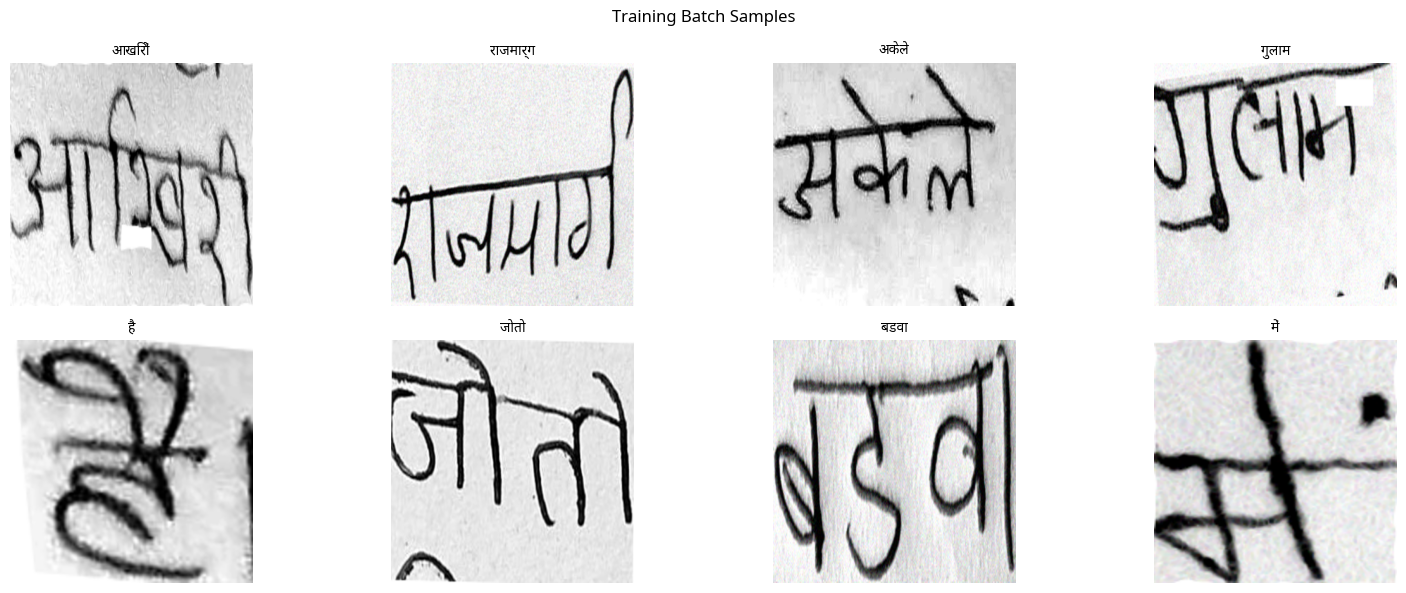

In [9]:
# Set Devanagari font globally for this plot
plt.rcParams["font.family"] = "Noto Sans Devanagari"
try:
    fm.fontManager.addfont(str(FONT_PATH))
except: pass

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
batch = next(iter(train_loader))
for i, ax in enumerate(axes.flat):
    if i >= batch["pixel_values"].shape[0]: break
    img = batch["pixel_values"][i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    label_ids = batch["labels"][i]
    label_ids = label_ids[label_ids != -100].tolist()
    text = decode_tokens(label_ids)
    ax.imshow(img)
    ax.set_title(text, fontsize=10, fontproperties=DEVA_FONT)
    ax.axis("off")
plt.suptitle("Training Batch Samples", fontweight="bold")
plt.tight_layout(); plt.show()


## 9. Load & Configure TrOCR Model

In [10]:
# Load pretrained model
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

# Smart embedding initialization for new Devanagari tokens
old_embed = model.decoder.get_input_embeddings().weight.data.clone()
embed_mean = old_embed.mean(dim=0)
old_op_weight = model.decoder.output_projection.weight.data.clone()
op_mean = old_op_weight.mean(dim=0)

model.decoder.resize_token_embeddings(VOCAB_SIZE)

with torch.no_grad():
    new_embed = model.decoder.get_input_embeddings().weight
    for i in range(VOCAB_SIZE):
        if i < old_embed.shape[0]:
            new_embed[i] = old_embed[i]
        else:
            new_embed[i] = embed_mean + torch.randn_like(embed_mean) * 0.02

    new_lm = model.decoder.output_projection.weight
    for i in range(VOCAB_SIZE):
        if i < old_op_weight.shape[0]:
            new_lm[i] = old_op_weight[i]
        else:
            new_lm[i] = op_mean + torch.randn_like(op_mean) * 0.02

print(f"Smart embedding init: {VOCAB_SIZE} tokens")
print(f"  (Original vocab had {old_embed.shape[0]} tokens)")
# NOTE: No Xavier cross-attn re-init (preserves pretrained weights)
# NOTE: No dropout override (pretrained values are calibrated)

# Configure model IDs
model.config.decoder_start_token_id = BOS_ID
model.config.pad_token_id = PAD_ID
model.config.eos_token_id = EOS_ID
model.config.vocab_size = VOCAB_SIZE

model.decoder.config.decoder_start_token_id = BOS_ID
model.decoder.config.pad_token_id = PAD_ID
model.decoder.config.eos_token_id = EOS_ID
model.decoder.config.vocab_size = VOCAB_SIZE

model.generation_config.max_length = MAX_TARGET_LEN
model.generation_config.no_repeat_ngram_size = 0
model.generation_config.length_penalty = 1.0
model.generation_config.num_beams = 1
model.generation_config.decoder_start_token_id = BOS_ID
model.generation_config.pad_token_id = PAD_ID
model.generation_config.eos_token_id = EOS_ID
model.generation_config.bos_token_id = BOS_ID

model = model.to(device)

enc_params = sum(p.numel() for p in model.encoder.parameters())
dec_params = sum(p.numel() for p in model.decoder.parameters())
total_params = enc_params + dec_params

print(f"Encoder: {enc_params:,} params")
print(f"Decoder: {dec_params:,} params")
print(f"Total:   {total_params:,} params")

print(f"\n" + "="*60)
print("  MODEL & TRAINING CONFIGURATION")
print("="*60)
print(f"  Model          : {MODEL_NAME}")
print(f"  Architecture   : ViT-DeiT (encoder) + GPT-2 (decoder)")
print(f"  Vocab size     : {VOCAB_SIZE}")
print(f"  Max target len : {MAX_TARGET_LEN}")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Image size     : 384 x 384 (RGB)")
print(f"  Phase A        : {EPOCHS_PHASE_A} epochs (decoder only, LR={LR_DECODER})")
print(f"  Phase B        : {EPOCHS_PHASE_B} epochs (full, enc LR={LR_ENCODER}, dec LR={LR_DECODER})")
print(f"  Total epochs   : {EPOCHS_PHASE_A + EPOCHS_PHASE_B}")
print(f"  Warmup steps   : {WARMUP_STEPS}")
print(f"  Grad clip      : {GRAD_CLIP}")
print(f"  Encoder params : {enc_params:,}")
print(f"  Decoder params : {dec_params:,}")
print(f"  Total params   : {total_params:,}")
print(f"  Train samples  : {len(train_df):,}")
print(f"  Val samples    : {len(val_df):,}")
print(f"  Test samples   : {len(test_df):,}")
print(f"  Batches/epoch  : {len(train_loader):,}")
print("="*60)
print("Model loaded and configured.")


pytorch_model.bin:   0%|          | 0.00/246M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Smart embedding init: 140 tokens
  (Original vocab had 64044 tokens)
Encoder: 21,960,192 params
Decoder: 6,917,632 params
Total:   28,877,824 params

  MODEL & TRAINING CONFIGURATION
  Model          : microsoft/trocr-small-handwritten
  Architecture   : ViT-DeiT (encoder) + GPT-2 (decoder)
  Vocab size     : 140
  Max target len : 32
  Batch size     : 16
  Image size     : 384 x 384 (RGB)
  Phase A        : 3 epochs (decoder only, LR=5e-05)
  Phase B        : 15 epochs (full, enc LR=1e-05, dec LR=5e-05)
  Total epochs   : 18
  Warmup steps   : 500
  Grad clip      : 1.0
  Encoder params : 21,960,192
  Decoder params : 6,917,632
  Total params   : 28,877,824
  Train samples  : 150,000
  Val samples    : 20,000
  Test samples   : 30,000
  Batches/epoch  : 9,375
Model loaded and configured.


## 10. CER / WER Evaluation

In [11]:
@torch.no_grad()
def evaluate_model(model, loader, max_samples=None, num_beams=4):
    """Evaluation with beam search and proper word-level WER."""
    model.eval()
    total_cer, total_wer, count = 0.0, 0.0, 0

    for batch in loader:
        if max_samples and count >= max_samples: break
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"]

        generated = model.generate(
            pixel_values,
            max_length=MAX_TARGET_LEN,
            num_beams=num_beams,
            decoder_start_token_id=BOS_ID,
        )

        for i in range(pixel_values.size(0)):
            if max_samples and count >= max_samples: break
            pred_text = decode_tokens(generated[i])
            gt_ids = labels[i][labels[i] != -100].tolist()
            gt_text = decode_tokens(gt_ids)

            if len(gt_text) == 0:
                count += 1
                continue

            ed = editdistance.eval(pred_text, gt_text)
            total_cer += ed / max(len(gt_text), 1)

            pred_words = pred_text.split()
            gt_words = gt_text.split()
            if len(gt_words) > 0:
                word_ed = editdistance.eval(pred_words, gt_words)
                total_wer += word_ed / len(gt_words)
            else:
                total_wer += (0.0 if len(pred_words) == 0 else 1.0)
            count += 1

    avg_cer = total_cer / max(count, 1)
    avg_wer = total_wer / max(count, 1)
    return avg_cer, avg_wer, count

print("Evaluation function ready.")


Evaluation function ready.


## 11. Training Setup

**Phase A (3 epochs):** Freeze encoder, train decoder only (LR=5e-5)

**Phase B (17 epochs):** Unfreeze all, differential LR (encoder=1e-5, decoder=5e-5)

Standard CrossEntropyLoss, SWA in last 3 Phase B epochs

In [12]:
def freeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = False
    print("Encoder FROZEN")

def unfreeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = True
    print("Encoder UNFROZEN")

def create_optimizer(model, phase="A"):
    if phase == "A":
        params = [p for p in model.decoder.parameters() if p.requires_grad]
        return optim.AdamW(params, lr=LR_DECODER, weight_decay=WEIGHT_DECAY)
    else:
        encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
        decoder_params = [p for p in model.decoder.parameters() if p.requires_grad]
        return optim.AdamW([
            {"params": encoder_params, "lr": LR_ENCODER},
            {"params": decoder_params, "lr": LR_DECODER},
        ], weight_decay=WEIGHT_DECAY)


scaler = torch.amp.GradScaler("cuda")
best_cer = float("inf")
history = {"loss": [], "val_cer": [], "val_wer": [], "lr": [], "epoch": [], "phase": []}

print("Training setup ready.")


Training setup ready.


## 12. Training Loop

In [13]:
from torch.optim.swa_utils import AveragedModel, SWALR

def train_one_epoch(model, loader, optimizer, scheduler, epoch_num, total_epochs):
    """v1 proven training loop — simple, no gradient accumulation."""
    model.train()
    epoch_loss, n_batches = 0.0, 0
    t0 = time.time()

    for bi, batch in enumerate(loader):
        optimizer.zero_grad()
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        with torch.amp.autocast("cuda"):
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        if scheduler: scheduler.step()

        epoch_loss += loss.item()
        n_batches += 1

        if (bi + 1) % 200 == 0:
            print(f"  [{bi+1}/{len(loader)}] loss={loss.item():.4f}")

    avg_loss = epoch_loss / max(n_batches, 1)
    elapsed = time.time() - t0
    return avg_loss, elapsed

def manual_update_bn(loader, swa_model, device):
    """Skip BN update if no BN layers (TrOCR uses LayerNorm only)."""
    has_bn = any(isinstance(m, torch.nn.modules.batchnorm._BatchNorm)
                 for m in swa_model.modules())
    if not has_bn:
        print("No BatchNorm layers — skipping BN update")
        return
    swa_model.train()
    with torch.no_grad():
        for batch in loader:
            pv = batch["pixel_values"].to(device)
            lb = batch["labels"].to(device)
            swa_model(pixel_values=pv, labels=lb)

def run_training(model, phase, n_epochs, start_epoch=1):
    global best_cer

    if phase == "A":
        freeze_encoder(model)
    else:
        unfreeze_encoder(model)

    optimizer = create_optimizer(model, phase)
    total_steps = n_epochs * len(train_loader)
    scheduler = get_scheduler("cosine", optimizer=optimizer,
                              num_warmup_steps=min(WARMUP_STEPS, total_steps//5),
                              num_training_steps=total_steps)

    # SWA for Phase B only
    use_swa = (phase == "B")
    swa_model = None
    swa_start_ep = n_epochs - 2
    if use_swa:
        swa_model = AveragedModel(model)
        print(f"SWA enabled: averaging from epoch {swa_start_ep}/{n_epochs}")

    print("\n" + "="*60)
    target_lr = LR_DECODER if phase == "A" else f"enc={LR_ENCODER}, dec={LR_DECODER}"
    print(f"PHASE {phase}: {n_epochs} epochs | LR={target_lr}")
    print("="*60)

    for ep in range(1, n_epochs + 1):
        global_ep = start_epoch + ep - 1
        print(f"\nEpoch {global_ep} (Phase {phase} - {ep}/{n_epochs})")
        print("-" * 40)

        avg_loss, elapsed = train_one_epoch(model, train_loader, optimizer, scheduler,
                                            global_ep, start_epoch + n_epochs - 1)

        if use_swa and ep >= swa_start_ep:
            swa_model.update_parameters(model)
            print(f"  [SWA] weights averaged (epoch {ep})")

        val_cer, val_wer, _ = evaluate_model(model, val_loader, max_samples=EVAL_SAMPLES)
        lr = optimizer.param_groups[0]["lr"]

        history["loss"].append(avg_loss)
        history["val_cer"].append(val_cer)
        history["val_wer"].append(val_wer)
        history["lr"].append(lr)
        history["epoch"].append(global_ep)
        history["phase"].append(phase)

        print(f"  loss={avg_loss:.4f} | CER={val_cer:.4f} | WER={val_wer:.4f} | "
              f"LR={lr:.2e} | time={elapsed:.0f}s")

        if val_cer < best_cer:
            best_cer = val_cer
            torch.save({
                "epoch": global_ep, "phase": phase,
                "model_state_dict": model.state_dict(),
                "val_cer": val_cer, "val_wer": val_wer,
                "vocab_size": VOCAB_SIZE,
                "char_to_token": char_to_token,
                "token_to_char": {str(k): v for k, v in token_to_char.items()},
            }, CKPT_DIR / "best_model.pt")
            print(f"  >> Best model saved! (CER={val_cer:.4f})")

    # Finalize SWA
    if use_swa and swa_model is not None:
        print("\nFinalizing SWA model...")
        manual_update_bn(train_loader, swa_model, device)
        # Copy SWA weights to model for evaluation
        orig_state = {k: v.clone() for k, v in model.state_dict().items()}
        model.load_state_dict(swa_model.module.state_dict())
        swa_cer, swa_wer, _ = evaluate_model(model, val_loader, max_samples=EVAL_SAMPLES)
        print(f"  SWA val CER={swa_cer:.4f} | WER={swa_wer:.4f}")
        if swa_cer < best_cer:
            best_cer = swa_cer
            torch.save({
                "epoch": global_ep, "phase": phase + "_SWA",
                "model_state_dict": model.state_dict(),
                "val_cer": swa_cer, "val_wer": swa_wer,
                "vocab_size": VOCAB_SIZE,
                "char_to_token": char_to_token,
                "token_to_char": {str(k): v for k, v in token_to_char.items()},
            }, CKPT_DIR / "best_model.pt")
            print(f"  >> SWA saved as best! (CER={swa_cer:.4f})")
        else:
            model.load_state_dict(orig_state)
            print(f"  SWA no improvement over {best_cer:.4f}, keeping original")

    return start_epoch + n_epochs

# Run training
next_epoch = run_training(model, "A", EPOCHS_PHASE_A, start_epoch=1)
next_epoch = run_training(model, "B", EPOCHS_PHASE_B, start_epoch=next_epoch)
print("\n" + "="*60)
print(f"Training complete! Best CER: {best_cer:.4f}")
print("="*60)


Encoder FROZEN

PHASE A: 3 epochs | LR=5e-05

Epoch 1 (Phase A - 1/3)
----------------------------------------
  [200/9375] loss=3.2606
  [400/9375] loss=2.8902
  [600/9375] loss=2.3027
  [800/9375] loss=2.1137
  [1000/9375] loss=2.0353
  [1200/9375] loss=2.3333
  [1400/9375] loss=2.0062
  [1600/9375] loss=1.9486
  [1800/9375] loss=1.9268
  [2000/9375] loss=1.6887
  [2200/9375] loss=1.8766
  [2400/9375] loss=1.6967
  [2600/9375] loss=1.7627
  [2800/9375] loss=1.8205
  [3000/9375] loss=1.8439
  [3200/9375] loss=1.9585
  [3400/9375] loss=1.6886
  [3600/9375] loss=1.4018
  [3800/9375] loss=1.0708
  [4000/9375] loss=1.5693
  [4200/9375] loss=1.5405
  [4400/9375] loss=1.5395
  [4600/9375] loss=1.3518
  [4800/9375] loss=1.2458
  [5000/9375] loss=1.7640
  [5200/9375] loss=1.4364
  [5400/9375] loss=1.2169
  [5600/9375] loss=1.3647
  [5800/9375] loss=1.0828
  [6000/9375] loss=0.9745
  [6200/9375] loss=1.1146
  [6400/9375] loss=1.1854
  [6600/9375] loss=1.2180
  [6800/9375] loss=1.2651
  [7000/9

## 13. Training Curves

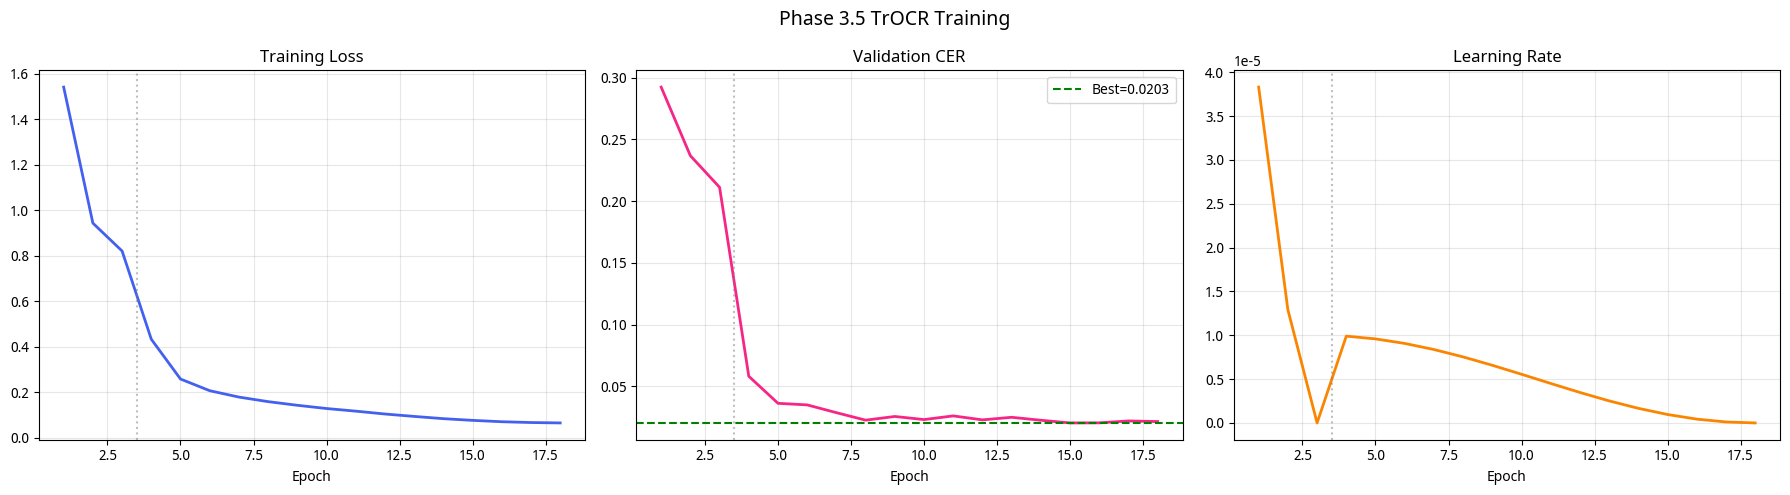

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["epoch"], history["loss"], color="#4361ee", lw=2)
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history["val_cer"], color="#f72585", lw=2)
axes[1].axhline(best_cer, color="green", ls="--", label=f"Best={best_cer:.4f}")
axes[1].set_title("Validation CER"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history["epoch"], history["lr"], color="#fb8500", lw=2)
axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Epoch"); axes[2].grid(alpha=0.3)

# Mark phase boundary
boundary = EPOCHS_PHASE_A + 0.5
for ax in axes:
    ax.axvline(boundary, color="gray", ls=":", alpha=0.5, label="Phase A|B")

plt.suptitle("Phase 3.5 TrOCR Training", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Final Test Evaluation

Load best checkpoint and evaluate with greedy + beam search + TTA on full test set.

In [15]:
# Load best model
ckpt = torch.load(CKPT_DIR / "best_model.pt", map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best model from epoch {ckpt['epoch']} (Phase {ckpt['phase']}, val CER={ckpt['val_cer']:.4f})")

# === Test-Time Augmentation (TTA) ===
def tta_predict(model, pil_img, processor, n_aug=5):
    """Generate predictions from original + augmented versions, majority vote."""
    model.eval()
    preds = []
    # Original
    pv = processor(images=pil_img, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        gen = model.generate(pv, max_length=MAX_TARGET_LEN, num_beams=4,
                             decoder_start_token_id=BOS_ID)
    preds.append(decode_tokens(gen[0]))
    # Augmented versions
    for _ in range(n_aug):
        aug_img = augment_image(pil_img)
        pv = processor(images=aug_img, return_tensors="pt").pixel_values.to(device)
        with torch.no_grad():
            gen = model.generate(pv, max_length=MAX_TARGET_LEN, num_beams=4,
                                 decoder_start_token_id=BOS_ID)
        preds.append(decode_tokens(gen[0]))
    # Majority vote
    from collections import Counter as C
    return C(preds).most_common(1)[0][0]

# Greedy evaluation
print("\n" + "="*60)
print("  GREEDY DECODING")
print("="*60)
t0 = time.time()
greedy_cer, greedy_wer, n = evaluate_model(model, test_loader, num_beams=1)
greedy_time = time.time() - t0
print(f"Test CER (greedy) : {greedy_cer:.4f}")
print(f"Test WER (greedy) : {greedy_wer:.4f}")
print(f"Char accuracy     : {(1-greedy_cer)*100:.2f}%")
print(f"Word accuracy     : {(1-greedy_wer)*100:.2f}%")
print(f"Time              : {greedy_time:.1f}s ({n} samples)")

# Beam search (width=4)
print("\n" + "="*60)
print(f"  BEAM SEARCH (width=4)")
print("="*60)
t0 = time.time()
beam4_cer, beam4_wer, n = evaluate_model(model, test_loader, num_beams=4)
beam4_time = time.time() - t0
print(f"Test CER (beam4)  : {beam4_cer:.4f}")
print(f"Test WER (beam4)  : {beam4_wer:.4f}")
print(f"Char accuracy     : {(1-beam4_cer)*100:.2f}%")
print(f"Word accuracy     : {(1-beam4_wer)*100:.2f}%")
print(f"Time              : {beam4_time:.1f}s")

# Beam search (width=8)
print("\n" + "="*60)
print(f"  BEAM SEARCH (width={NUM_BEAMS_TEST})")
print("="*60)
t0 = time.time()
beam_cer, beam_wer, n = evaluate_model(model, test_loader, num_beams=NUM_BEAMS_TEST)
beam_time = time.time() - t0
print(f"Test CER (beam)   : {beam_cer:.4f}")
print(f"Test WER (beam)   : {beam_wer:.4f}")
print(f"Char accuracy     : {(1-beam_cer)*100:.2f}%")
print(f"Word accuracy     : {(1-beam_wer)*100:.2f}%")
print(f"Time              : {beam_time:.1f}s")

Loaded best model from epoch 15 (Phase B, val CER=0.0203)

  GREEDY DECODING
Test CER (greedy) : 0.0531
Test WER (greedy) : 0.1288
Char accuracy     : 94.69%
Word accuracy     : 87.12%
Time              : 572.3s (30000 samples)

  BEAM SEARCH (width=4)
Test CER (beam4)  : 0.0533
Test WER (beam4)  : 0.1290
Char accuracy     : 94.67%
Word accuracy     : 87.10%
Time              : 1296.0s

  BEAM SEARCH (width=8)
Test CER (beam)   : 0.0534
Test WER (beam)   : 0.1290
Char accuracy     : 94.66%
Word accuracy     : 87.10%
Time              : 2255.2s

  COMPARISON: Phase 3 CRNN vs Phase 3.5 TrOCR


TypeError: '>' not supported between instances of 'str' and 'int'

In [18]:
# Comparison
print("\n" + "="*60)
print("  COMPARISON: Phase 3 CRNN vs Phase 3.5 TrOCR")
print("="*60)
print(f"{'Metric':<20} {'CRNN (Phase 3)':>16} {'TrOCR (Phase 3.5)':>18}")
print("-" * 56)
print(f"{'CER (greedy)':<20} {'0.0703':>16} {greedy_cer:>18.4f}")
print(f"{'WER (greedy)':<20} {'0.1577':>16} {greedy_wer:>18.4f}")
print(f"{'CER (beam)':<20} {'0.0696':>16} {beam_cer:>18.4f}")
print(f"{'WER (beam)':<20} {'0.1561':>16} {beam_wer:>18.4f}")
print(f"{'Char acc (beam)':<20} {'93.04%':>16} {(1-beam_cer)*100:>17.2f}%")
print(f"{'Word acc (beam)':<20} {'84.39%':>16} {(1-beam_wer)*100:>17.2f}%")


  COMPARISON: Phase 3 CRNN vs Phase 3.5 TrOCR
Metric                 CRNN (Phase 3)  TrOCR (Phase 3.5)
--------------------------------------------------------
CER (greedy)                   0.0703             0.0531
WER (greedy)                   0.1577             0.1288
CER (beam)                     0.0696             0.0534
WER (beam)                     0.1561             0.1290
Char acc (beam)                93.04%             94.66%
Word acc (beam)                84.39%             87.10%


## 15. Sample Predictions

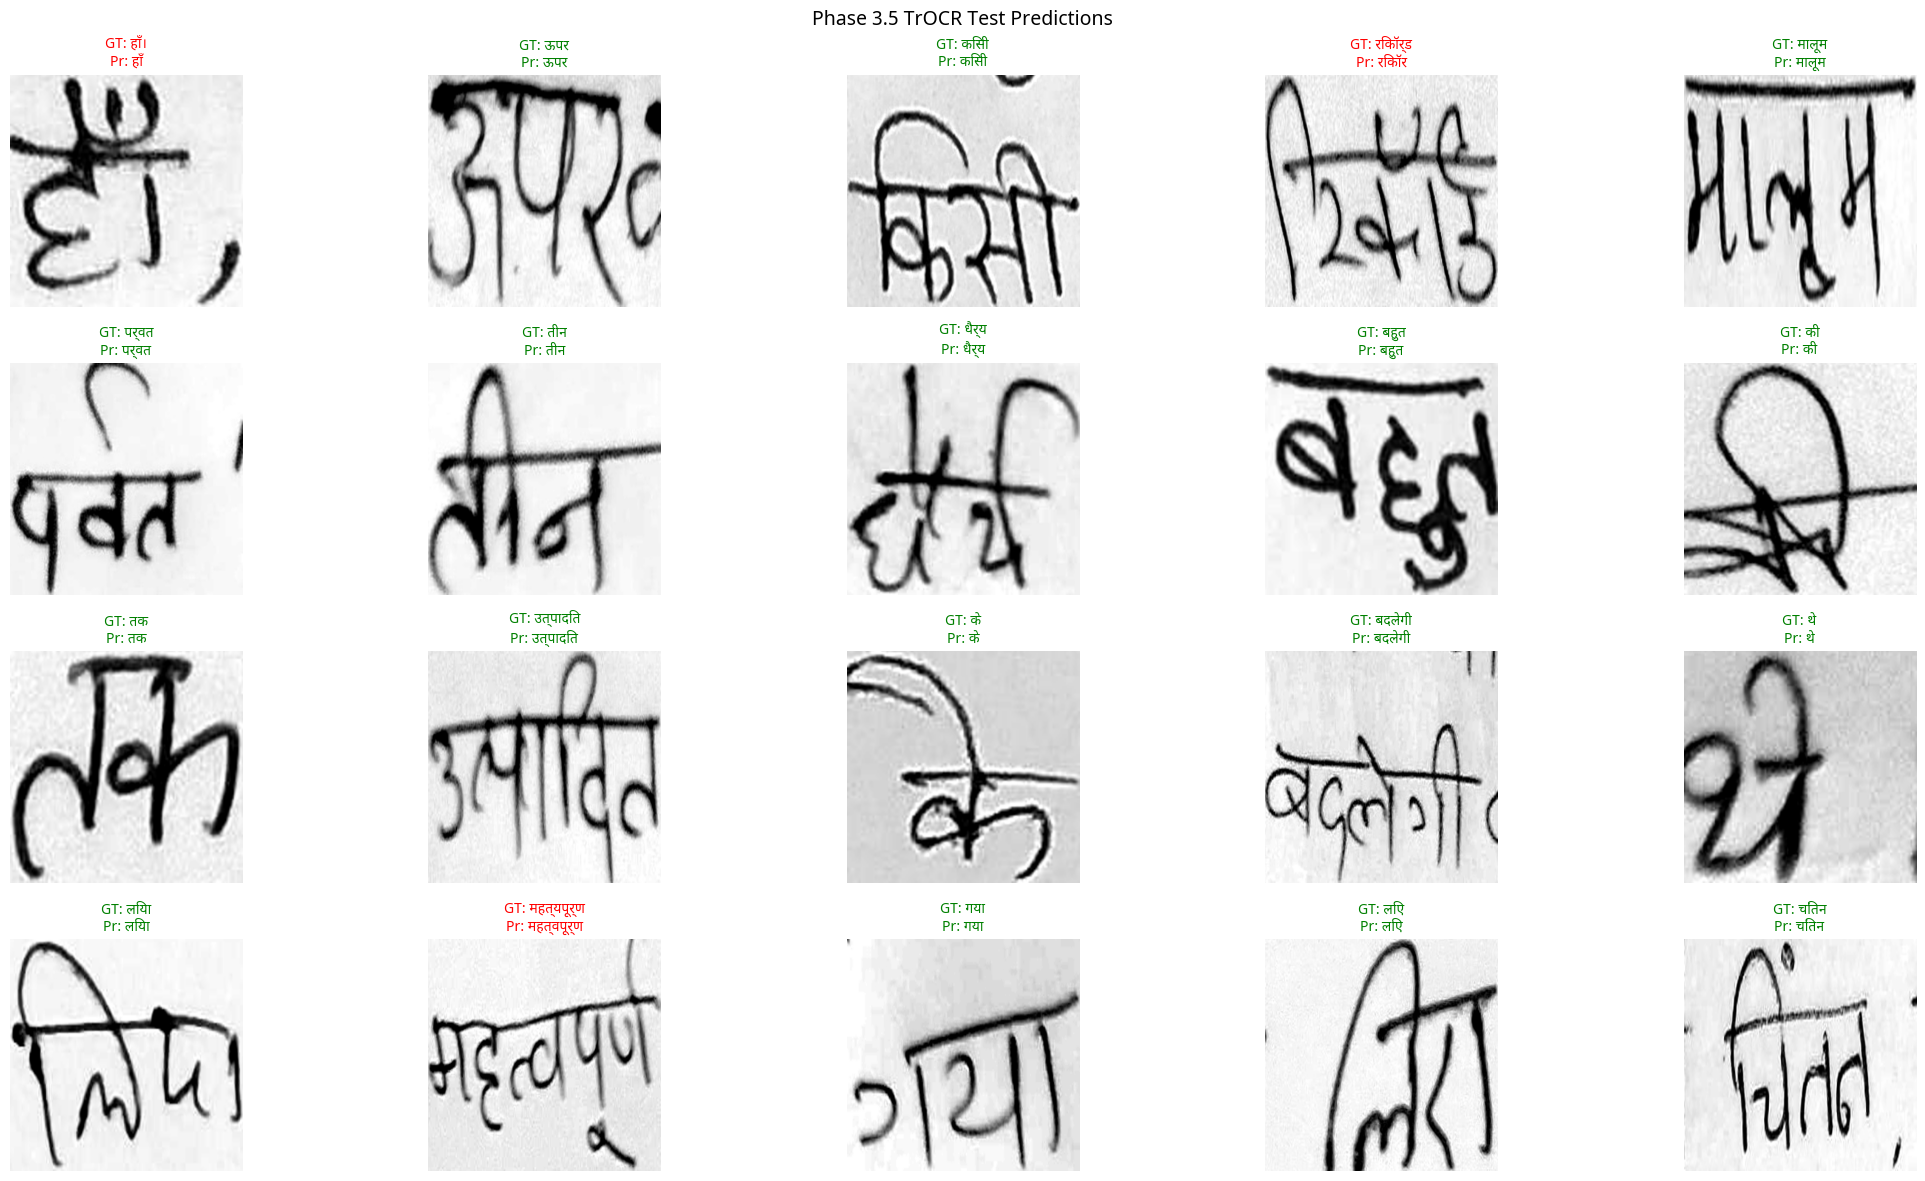

In [19]:
model.eval()
sample_loader = DataLoader(test_dataset, batch_size=20, shuffle=True, collate_fn=collate_fn)
batch = next(iter(sample_loader))

with torch.no_grad():
    generated = model.generate(
        batch["pixel_values"].to(device),
        max_length=MAX_TARGET_LEN,
        num_beams=NUM_BEAMS_TEST,
        decoder_start_token_id=BOS_ID,
    )

fig, axes = plt.subplots(4, 5, figsize=(22, 12))
fig.suptitle("Phase 3.5 TrOCR Test Predictions", fontweight="bold", fontsize=14)

for i, ax in enumerate(axes.flat):
    if i >= batch["pixel_values"].shape[0]: ax.axis("off"); continue
    img = batch["pixel_values"][i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    pred_text = decode_tokens(generated[i])
    gt_ids = batch["labels"][i]
    gt_ids = gt_ids[gt_ids != -100].tolist()
    gt_text = decode_tokens(gt_ids)
    cer = editdistance.eval(pred_text, gt_text) / max(len(gt_text), 1)
    color = "green" if cer < 0.1 else "red"
    ax.imshow(img)
    ax.set_title(f"GT: {gt_text}\nPr: {pred_text}", fontsize=9,
                 fontproperties=DEVA_FONT, color=color)
    ax.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "test_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


## 16. Error Analysis


TOP 15 WORST PREDICTIONS (Test subset)
#    CER      GT Length  Ground Truth                   Prediction                    
--------------------------------------------------------------------------------
1    3.0000   1          छ                              हुए                           
2    2.0000   2          ऋण                             च्रदण                         
3    1.5000   2          है                             हूँ।                          
4    1.0000   1          ह                              यह                            
5    1.0000   2          कर                             करति                          
6    1.0000   2          है                             हैं।                          
7    0.8333   6          उपलब्ध                         साल्लष्ध                      
8    0.8000   5          वट्टा                          बहा                           
9    0.7500   4          मसला                           गएना                          
10   0.72

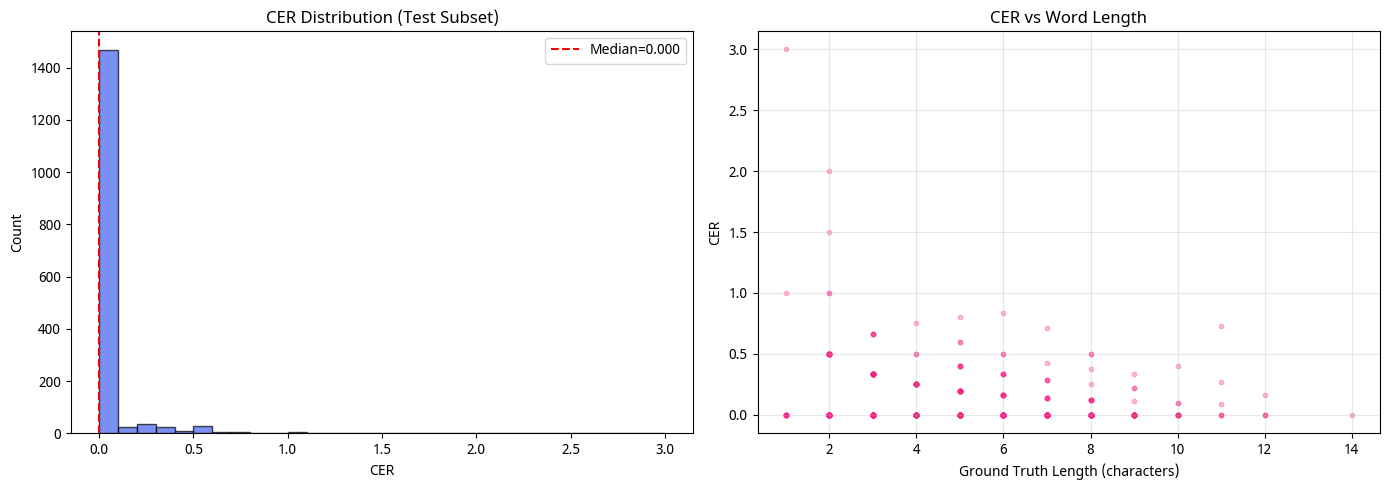


Char          Total   Errors   Error%
------------------------------------
ट                24        6    25.0%
़                20        4    20.0%
ृ                 6        1    16.7%
श                42        6    14.3%
ण                24        3    12.5%
ष                24        3    12.5%
छ                19        2    10.5%
ठ                10        1    10.0%
ध                31        3     9.7%
ु                73        7     9.6%
ख                34        3     8.8%
्               245       19     7.8%
ं               198       15     7.6%
न               249       17     6.8%

Exact match on subset: 1467/1600 (91.7%)


In [20]:
model.eval()
errors_list = []          # for worst predictions and plots
char_errors = Counter()
char_totals = Counter()

sample_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                               collate_fn=collate_fn)

with torch.no_grad():
    for bi, batch in enumerate(sample_test_loader):
        if bi >= 50: break   # same limit as before
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"]

        # Greedy decoding for speed (you can use beam if you prefer)
        generated = model.generate(pixel_values, max_length=MAX_TARGET_LEN,
                                   num_beams=1, decoder_start_token_id=BOS_ID)

        for i in range(pixel_values.size(0)):
            pred = decode_tokens(generated[i])
            gt_ids = labels[i][labels[i] != -100].tolist()
            gt = decode_tokens(gt_ids)

            # CER
            cer = editdistance.eval(pred, gt) / max(len(gt), 1) if gt else float(len(pred) > 0)

            errors_list.append({
                'gt': gt,
                'pred': pred,
                'cer': cer,
                'gt_len': len(gt)
            })

            # Per‑character errors (for final table)
            for ch in gt:
                char_totals[ch] += 1
            if pred != gt:
                for j, ch in enumerate(gt):
                    if j >= len(pred) or pred[j] != ch:
                        char_errors[ch] += 1

# ---------- Convert to DataFrame and sort ----------
errors_df = pd.DataFrame(errors_list).sort_values('cer', ascending=False)

# --- 1. Print Top-15 worst predictions ---
print("\n" + "="*80)
print("TOP 15 WORST PREDICTIONS (Test subset)")
print("="*80)
print(f"{'#':<4} {'CER':<8} {'GT Length':<10} {'Ground Truth':<30} {'Prediction':<30}")
print("-"*80)
for rank, (_, row) in enumerate(errors_df.head(15).iterrows(), 1):
    print(f"{rank:<4} {row['cer']:.4f}   {row['gt_len']:<10} {row['gt']:<30} {row['pred']:<30}")

# --- 2 & 3. Plots: CER distribution and CER vs word length ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 2: CER distribution histogram
axes[0].hist(errors_df['cer'], bins=30, color='#4361ee', edgecolor='black', alpha=0.7)
axes[0].set_title('CER Distribution (Test Subset)')
axes[0].set_xlabel('CER')
axes[0].set_ylabel('Count')
axes[0].axvline(errors_df['cer'].median(), color='red', ls='--',
                label=f'Median={errors_df["cer"].median():.3f}')
axes[0].legend()

# Plot 3: CER vs. word length
axes[1].scatter(errors_df['gt_len'], errors_df['cer'],
                alpha=0.3, s=10, color='#f72585')
axes[1].set_title('CER vs Word Length')
axes[1].set_xlabel('Ground Truth Length (characters)')
axes[1].set_ylabel('CER')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 4. Per‑character error table (original) ---
print(f"\n{'Char':<10} {'Total':>8} {'Errors':>8} {'Error%':>8}")
print("-" * 36)
for ch in sorted(char_totals.keys(),
                 key=lambda c: char_errors.get(c, 0) / max(char_totals[c], 1),
                 reverse=True)[:20]:
    t = char_totals[ch]
    e = char_errors.get(ch, 0)
    if t >= 5:
        print(f"{ch:<10} {t:>8} {e:>8} {e/t*100:>7.1f}%")

# Overall exact‑match
exact = sum(1 for _, r in errors_df.iterrows() if r['gt'] == r['pred'])
print(f"\nExact match on subset: {exact}/{len(errors_df)} ({exact/len(errors_df)*100:.1f}%)")

## 17. Save Final Artifacts

In [21]:
# Save training history
with open(RESULTS_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)

# Save results summary
results = {
    "model": MODEL_NAME,
    "vocab_size": VOCAB_SIZE,
    "best_epoch": ckpt["epoch"],
    "best_val_cer": ckpt["val_cer"],
    "best_val_wer": ckpt["val_wer"],
    "test_cer_greedy": greedy_cer,
    "test_wer_greedy": greedy_wer,
    "test_cer_beam": beam_cer,
    "test_wer_beam": beam_wer,
    "char_accuracy_beam": (1 - beam_cer) * 100,
    "word_accuracy_beam": (1 - beam_wer) * 100,
    "total_params": sum(p.numel() for p in model.parameters()),
    "epochs_phase_a": EPOCHS_PHASE_A,
    "epochs_phase_b": EPOCHS_PHASE_B,
    "batch_size": BATCH_SIZE,
    "dataset_train": len(train_df),
    "dataset_val": len(val_df),
    "dataset_test": len(test_df),
    "phase3_crnn_cer_beam": 0.0696,
    "phase3_crnn_wer_beam": 0.1561,
}
with open(RESULTS_DIR / "phase3_5_results.json", "w") as f:
    json.dump(results, f, indent=2)

# Copy model
import shutil
shutil.copy(CKPT_DIR / "best_model.pt", OUTPUT_DIR / "best_model_trocr.pt")

print("="*60)
print("PHASE 3.5 COMPLETE")
print("="*60)
print(f"Architecture    : TrOCR-Small (ViT + GPT-2)")
print(f"Parameters      : {sum(p.numel() for p in model.parameters()):,}")
print(f"Best val CER    : {ckpt['val_cer']:.4f}")
print(f"Test CER (grdy) : {greedy_cer:.4f}")
print(f"Test WER (grdy) : {greedy_wer:.4f}")
print(f"Test CER (beam) : {beam_cer:.4f}")
print(f"Test WER (beam) : {beam_wer:.4f}")
print(f"Char acc (beam) : {(1-beam_cer)*100:.2f}%")
print(f"Word acc (beam) : {(1-beam_wer)*100:.2f}%")
print(f"\nCheckpoint : {CKPT_DIR / 'best_model.pt'}")
print(f"Results    : {RESULTS_DIR}")


PHASE 3.5 COMPLETE
Architecture    : TrOCR-Small (ViT + GPT-2)
Parameters      : 28,877,824
Best val CER    : 0.0203
Test CER (grdy) : 0.0531
Test WER (grdy) : 0.1288
Test CER (beam) : 0.0534
Test WER (beam) : 0.1290
Char acc (beam) : 94.66%
Word acc (beam) : 87.10%

Checkpoint : /kaggle/working/phase3_5/checkpoints/best_model.pt
Results    : /kaggle/working/phase3_5/results
